In [44]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [45]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
eps = 0.1
s = 0.2
gamma = 0.2
sol = model.solve_equilibrium_o(eps, s, gamma)

print("Equilibrium:", sol)

check = model.check_interior(sol["p1"], sol["p2"], eps, s, gamma)

print("Interior check:", check)

Equilibrium: {'p1': 0.5391480114203615, 'p2': 0.48916095394630654, 'converged': True, 'iterations': 2}
Interior check: {'z_positive': True, 'theta_interior': True, 'support_ok': True, 'interior': True}


In [9]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.25, 25) # search cost (avoid 0 exactly)
results = []

In [27]:
prev_p1, prev_p2 = 0.5, 0.5

for eps in eps_grid:
    for s in s_grid:
        
        try:
            p1, p2, converged = model.solve_equilibrium(
                eps, s, gamma,
                p1_init=prev_p1,
                p2_init=prev_p2
            )
            
            # update warm start
            prev_p1, prev_p2 = p1, p2
            
            # compute objects
            theta = model.theta_star(p1, p2, eps, s, gamma)
            interior = model.check_interior(p1, p2, eps, s, gamma)["interior"]
            
            results.append({
                "eps": eps,
                "s": s,
                "p1": p1,
                "p2": p2,
                "theta": theta,
                "interior": interior,
                "converged": converged
            })
        
        except Exception as e:
            results.append({
                "eps": eps,
                "s": s,
                "p1": np.nan,
                "p2": np.nan,
                "theta": np.nan,
                "interior": False,
                "converged": False
            })

In [28]:
df = pd.DataFrame(results)
df["theta"] = df["theta"].clip(0, 1)
p1_mat = df.pivot(index="s", columns="eps", values="p1")
p2_mat = df.pivot(index="s", columns="eps", values="p2")
theta_mat = df.pivot(index="s", columns="eps", values="theta")
interior_mat = df.pivot(index="s", columns="eps", values="interior")

In [56]:
# Define parameter cases #

gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.1, 0.1),
    (0.2, 0.1),
    (0.2, 0.2),
    (0.2, 0.3)
]

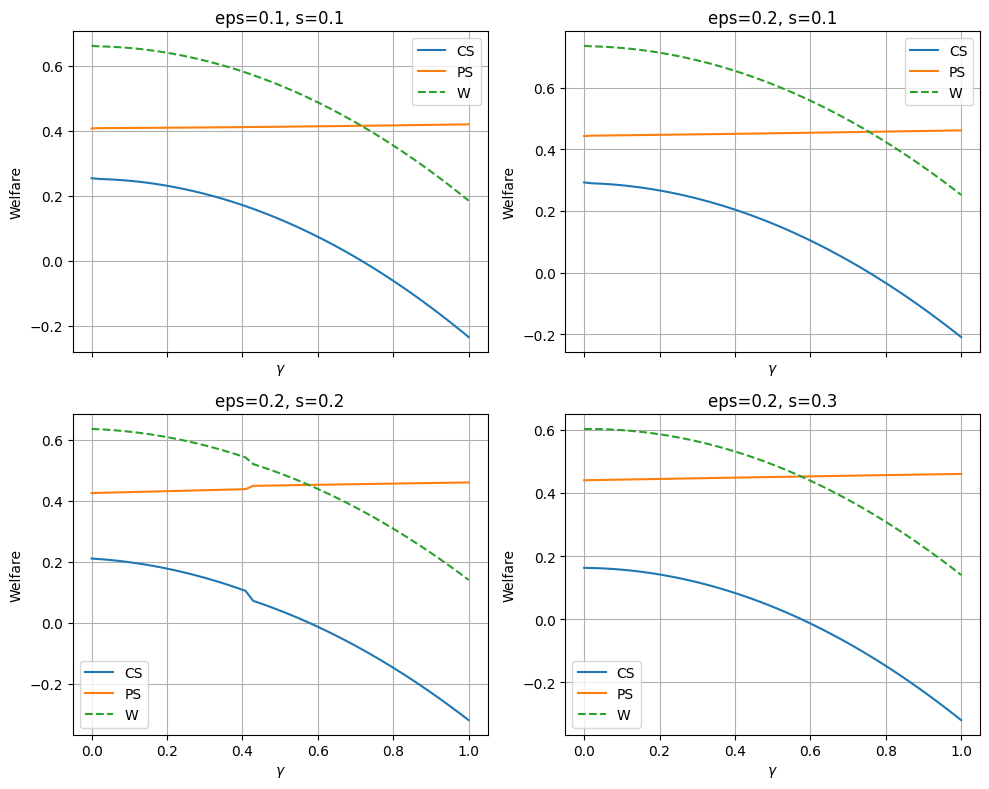

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

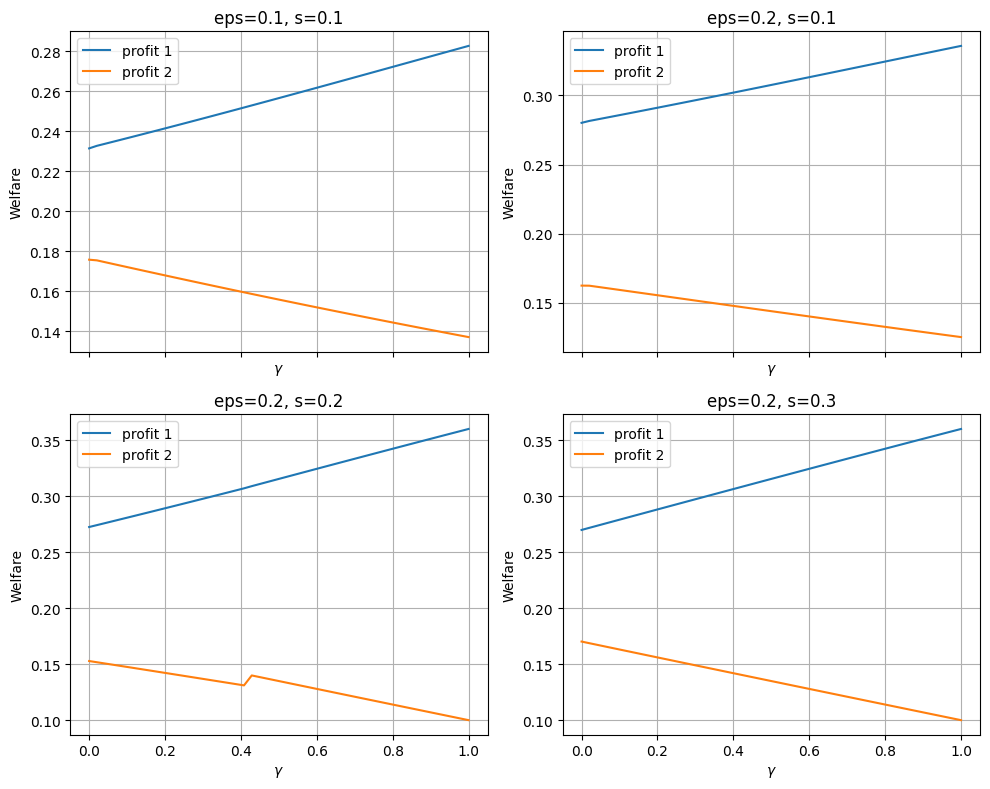

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

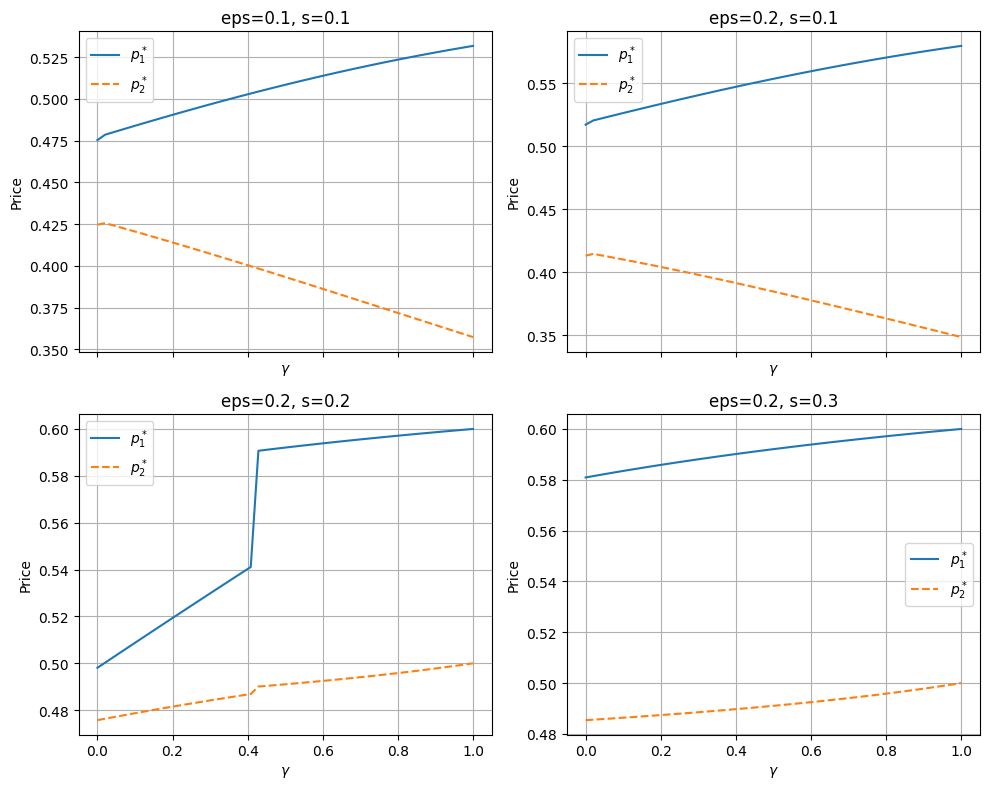

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, theta = model.compute_equilibrium_path(eps, s, gamma_grid)
    
    ax.plot(gamma_grid, p1, label=r"$p_1^*$")
    ax.plot(gamma_grid, p2, linestyle="--", label=r"$p_2^*$")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()